In [47]:
import bchlib as bch
import os
import numpy as np
from tqdm import trange
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
m = 14
t = 10

bch = bch.BCH(m=m, t=t)
#data shoudl be 512 bytes
data = os.urandom(512)
ecc = bch.encode(data)
#print the number of parity bits
print(f'Number of parity bytes: {len(ecc)}')
print(f'The proposed configuration fits in the OOB area: {len(ecc)+4 <= 69}')

Number of parity bytes: 18
The proposed configuration fits in the OOB area: True


# Scrubbing Frequency Concerns

In [ ]:
#  Knowns
mission_lifetime = 2            # years
word_size = 512 + 69            # bytes
spenvis_rate = 6e-12            # errors per bit per second
num_words = 2304 * 32           # num errors per block
t_bch = 10

#  Parameters
scrubbing_frequency = 5         # days
t = scrubbing_frequency * 24 * 3600 
lam = spenvis_rate * 8 * word_size * t # errors per word per scrubbing period
n_scrub = int(mission_lifetime * 365 / scrubbing_frequency)
counter = 0
uncorrectables = 0

block = np.zeros(num_words, dtype=int)
runs = 1000
simulations = trange(runs, desc="Simulation", unit="run")
erases = np.zeros(runs, dtype=int)
unc_vec = np.zeros(runs, dtype=int)

for run in simulations:
    block.fill(0)
    counter = 0
    uncorrectables = 0
    for n in range(n_scrub):
        k = np.random.poisson(lam, num_words)
        block += k

        extra = np.random.choice([0,1,2], size=(num_words, k.max()), p=[0.8,0.15,0.05])
        mask = np.arange(k.max()) < k[:, None]
        block += (extra * mask).sum(axis=1)

        uncorrectables += np.sum(block > t_bch)

        if block.max() >= t_bch - 1:
            counter += 1
            block.fill(0)

    unc_vec[run] = uncorrectables
    erases[run] = counter
    simulations.set_postfix({f"Average uncorrectables": np.mean(unc_vec[:run+1])})


Simulation: 100%|██████████| 1000/1000 [12:05<00:00,  1.38run/s, Average uncorrectables=0.072]


In [55]:
# Save results on a file but add to what is already there
with open("bch_erases.csv", "a") as f:
    for run in range(runs):
        f.write(f"{t_bch},{erases[run]},{unc_vec[run]}\n")

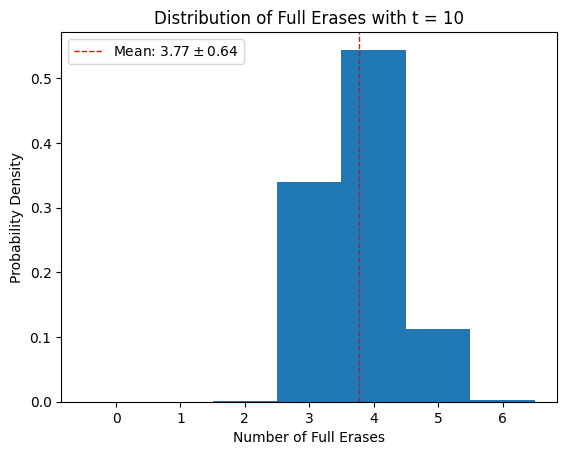

In [69]:
data = pd.read_csv("bch_erases.csv", header=None, names=["t_bch", "erases", "uncorrectables"])
erases = data['erases'][data['t_bch'] == 10].values
bins = np.arange(0, max(erases)+2) - 0.5
plt.hist(erases, bins=bins, density=True)
plt.title('Distribution of Full Erases with t = 10')
plt.xlabel('Number of Full Erases')
plt.ylabel('Probability Density')
plt.axvline(np.mean(erases), color='red', linestyle='dashed', linewidth=1, \
             label=rf'Mean: ${np.mean(erases):.2f}\pm{np.std(erases):.2f}$')
# force x axis to have only integers
plt.xticks(np.arange(0, max(erases)+1, 1))
plt.legend()